# **Classification using FCNN on Churn_Modelling Dataset**

# EDA

In [1]:
import pandas as pd
df = pd.read_csv('/content/Churn_Modelling.csv')

In [2]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


No null entries

In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


<Axes: title={'center': 'Customer Churn Distribution'}>

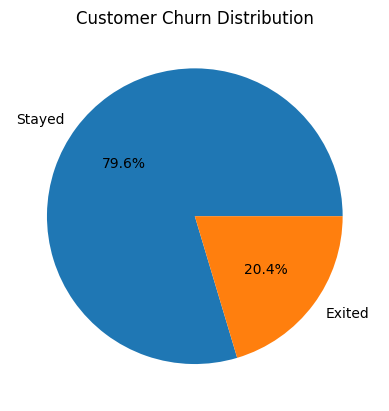

In [5]:
df['Exited'].value_counts(normalize=True).plot.pie(
    autopct='%1.1f%%',
    labels=['Stayed', 'Exited'],
    ylabel='',
    title='Customer Churn Distribution'
)

This indicates that the dataset is highly unbalanced (80% , 20%)

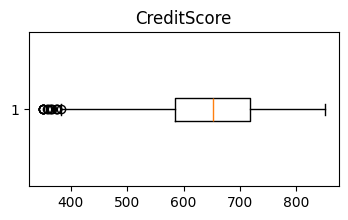

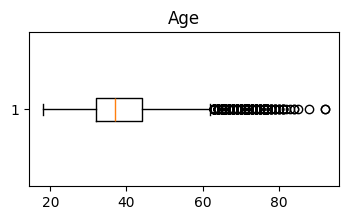

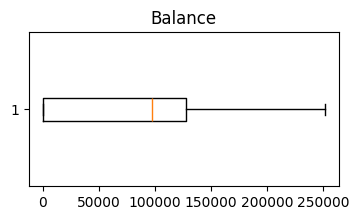

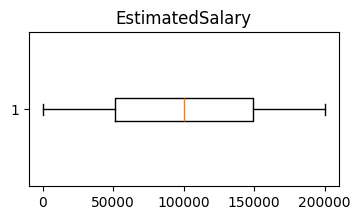

In [6]:
import matplotlib.pyplot as plt

numeric_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

for col in numeric_cols:
    plt.figure(figsize=(4,2))
    plt.boxplot(df[col], vert=False)
    plt.title(col)
    plt.show()

outliers in this case real customer data not data entry errors (ex: it appears that there are some outliers in the age but actually >90 age is possible not an error) so the model should learn how to deal with such cases + also standarad scaler help with reducing the effect of outliers while keeping thr important info, so i chose not to remove them

# Data preprocessing

In [7]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1) #these features has nothing to do with the prediction wether the customer is going to leave or not
                                                             #so these are dropped

In [8]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [9]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})   # encode non-numerical features 9gender is mapped to 1 and 0 , while
df = pd.get_dummies(df, columns=['Geography'], drop_first=True) # one hot encoded

In [10]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


# Data Splitting

In [11]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [12]:
from sklearn.model_selection import train_test_split  #stratify is important in case of the class imbalance , it preserves that each split contain the same classes distribution

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [13]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(8000, 11) (2000, 11)
Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64


# Feature scaling

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
X_train_scaled[0:5]

array([[ 1.058568  ,  0.90750738,  1.71508648,  0.68472287, -1.22605881,
        -0.91025649,  0.64104192, -1.030206  ,  1.04208392, -0.57831252,
        -0.57773517],
       [ 0.91362605,  0.90750738, -0.65993547, -0.6962018 ,  0.41328769,
        -0.91025649,  0.64104192, -1.030206  , -0.62355635,  1.72916886,
        -0.57773517],
       [ 1.07927399, -1.10191942, -0.18493108, -1.73189531,  0.60168748,
         0.80883036,  0.64104192,  0.97067965,  0.30812779,  1.72916886,
        -0.57773517],
       [-0.92920731,  0.90750738, -0.18493108, -0.00573947, -1.22605881,
         0.80883036,  0.64104192, -1.030206  , -0.29019914, -0.57831252,
        -0.57773517],
       [ 0.42703522,  0.90750738,  0.95507945,  0.3394917 ,  0.54831832,
         0.80883036, -1.55996038,  0.97067965,  0.13504224,  1.72916886,
        -0.57773517]])

# Building the FCNN

In [16]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')  #gives a probability between 0 and 1 -> for binary classification.
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
early_stop = keras.callbacks.EarlyStopping(   #prevents overfitting
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Fixing the class imbalance
this is used to give  the minority class higher penalties when misclassifing it

Class 0 gets a weight of 0.6, while class 1 gets a weight of 2 -> so this prevent the  model from becoming biased toward majority class and just predict 0 because it is the most frequent

In [18]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(0.6279434850863422), 1: np.float64(2.4539877300613497)}


# Model training

In [19]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4484 - loss: 0.6613 - val_accuracy: 0.6250 - val_loss: 0.6512
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6395 - loss: 0.6131 - val_accuracy: 0.7000 - val_loss: 0.6012
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6792 - loss: 0.5901 - val_accuracy: 0.7237 - val_loss: 0.5726
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7009 - loss: 0.5772 - val_accuracy: 0.7362 - val_loss: 0.5482
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7125 - loss: 0.5593 - val_accuracy: 0.7412 - val_loss: 0.5276
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7220 - loss: 0.5529 - val_accuracy: 0.7475 - val_loss: 0.5127
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7184 - loss: 0.5476 - val_accuracy: 0.7531 - val_loss: 0.4985
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7372 - loss: 0.5370 - val_accuracy: 0.

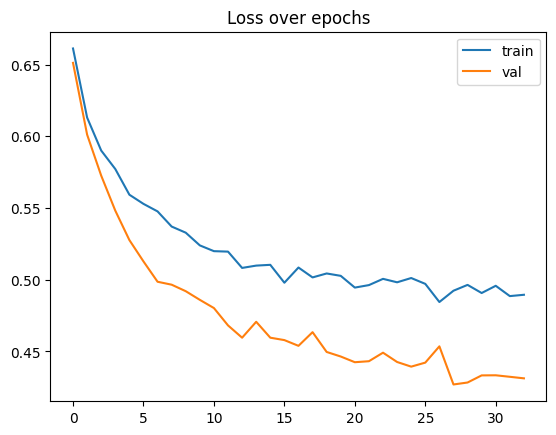

In [20]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend(); plt.title('Loss over epochs')
plt.show()

In [21]:
y_proba = model.predict(X_test_scaled).ravel()
y_pred = (y_proba >= 0.6).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.91      0.91      1593
           1       0.64      0.60      0.62       407

    accuracy                           0.85      2000
   macro avg       0.77      0.76      0.76      2000
weighted avg       0.85      0.85      0.85      2000



In [24]:
from sklearn.metrics import roc_auc_score
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

ROC-AUC: 0.8585696636544093


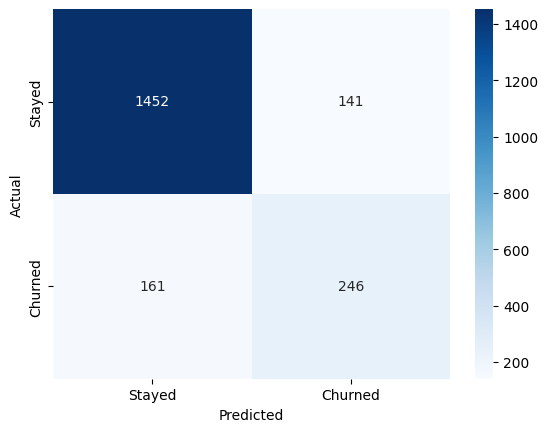

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed','Churned'],
            yticklabels=['Stayed','Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Conclusion

A fully connected neural network (16 -> 8 hidden units with dropout)
was trained to predict customer churn on an imbalanced dataset ( 80% stayed, 20% churned)

Class weighting was used during training to fix the imbalance and early stopping to prevent overfitting  also confirmed by the loss curve, where
training was stopped once validation losss began increasing

The classification threshold was tuned i tried diffrent values and .6 was found to be the best

**Final test set performance (churn class):** the minor class
- Precision: 0.64
- Recall: 0.60
- F1-score: 0.62
- Overall accuracy: 0.85
- ROC-AUC: 0.86